In [ ]:
install.packages("yacca")
install.packages("flextable")
install.packages("ggfortify")
install.packages("factoextra")
install.packages("psych")

install.packages("nFactors")
install.packages("reshape2")
install.packages("GPArotation")
install.packages("Hmisc")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘quantreg’, ‘car’, ‘rstatix’, ‘FactoMineR’, ‘ggpubr’


Warning message in install.packages("factoextra"):
“installation of package ‘quantreg’ had non-zero exit status”
Warning message in install.packages("factoextra"):
“installation of package ‘car’ had non-zero exit status”
Warning message in install.packages("factoextra"):
“installation of package ‘rstatix’ had non-zero exit status”
Warning message in install.packages("factoextra"):
“installation of package ‘FactoMineR’ had non-zero exit status”
Warning message in install.packages("factoextra"):
“installation of package ‘ggpubr’ had non-zero exit status”
Warning message in in

In [ ]:
library(tidyverse)
library(yacca)
library(flextable)
library(ggfortify)
library(psych)

library(nFactors)
library(reshape2)
library(GPArotation)
library(Hmisc)


Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘GPArotation’


The following objects are masked from ‘package:psych’:

    equamax, varimin



Attaching package: ‘Hmisc’


The following object is masked from ‘package:psych’:

    describe


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




In [ ]:
df <- read.csv("wine_quality.csv" )%>% select(-X)
head(df)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,0.2295089,2.1357671,-2.461304,-0.8151729,0.6245540,-1.19360132,-1.4633485,1.0353218,1.78174153,0.2503549,-0.9298923,5,red
2,0.5502613,3.0128173,-2.461304,-0.4981755,1.2819991,-0.01394352,-0.5132599,0.7021270,-0.09693675,1.0592133,-0.5588698,5,red
3,0.5502613,2.4380317,-2.104518,-0.6257399,1.1040115,-0.75468404,-0.8167782,0.7687793,0.27727168,0.8625487,-0.5588698,5,red
4,2.8027279,-0.3371086,1.583940,-0.8151729,0.5943516,-0.57498216,-0.6686619,1.1019407,-0.34939085,0.3893962,-0.5588698,6,red
5,0.2295089,2.1357671,-2.461304,-0.8151729,0.6245540,-1.19360132,-1.4633485,1.0353218,1.78174153,0.2503549,-0.9298923,5,red
6,0.2295089,1.9282711,-2.461304,-0.8666191,0.5943516,-0.95841323,-1.2370071,1.0353218,1.78174153,0.2503549,-0.9298923,5,red


In [ ]:
df$quality_group <- cut(
  df$quality,
  breaks = c(-Inf, 3, 6, Inf),
  labels = c("Low", "Medium", "High"),
  right = TRUE
)
df <- df %>%
  select(-quality)

# **Canonical Corrolation Analysis**

In [ ]:
set_A = c("free_sulfur_dioxide","total_sulfur_dioxide","citric_acid","alcohol","residual_sugar")
set_B = c("volatile_acidity","fixed_acidity","chlorides","density","sulphates","pH")

data_A = df %>%
  select(all_of(set_A))
data_B = df %>%
  select(all_of(set_B))


cca_model <- cca(data_A, data_B)
summary(cca_model)


Canonical Correlation Analysis - Summary


Canonical Correlations:

     CV 1      CV 2      CV 3      CV 4      CV 5 
0.9613498 0.6942243 0.5794601 0.2535801 0.1089286 

Shared Variance on Each Canonical Variate:

      CV 1       CV 2       CV 3       CV 4       CV 5 
0.92419341 0.48194740 0.33577396 0.06430288 0.01186545 

Bartlett's Chi-Squared Test:

          rho^2      Chisq df    Pr(>X)    
CV 1 9.2419e-01 2.2263e+04 30 < 2.2e-16 ***
CV 2 4.8195e-01 6.8449e+03 20 < 2.2e-16 ***
CV 3 3.3577e-01 2.9140e+03 12 < 2.2e-16 ***
CV 4 6.4303e-02 4.6860e+02  6 < 2.2e-16 ***
CV 5 1.1865e-02 7.1344e+01  2 3.331e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Canonical Variate Coefficients:

	X Vars:
                            CV 1        CV 2        CV 3        CV 4
free_sulfur_dioxide  -0.02025364 -0.03414962  0.09860699 -0.90863531
total_sulfur_dioxide  0.16125970  0.92353321 -0.49492550  0.05898451
citric_acid          -0.02912548  0.24112868  1.09923635  0

# **Factor Analysis**

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(numeric_all)

  # Now:
  data %>% select(all_of(numeric_all))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 


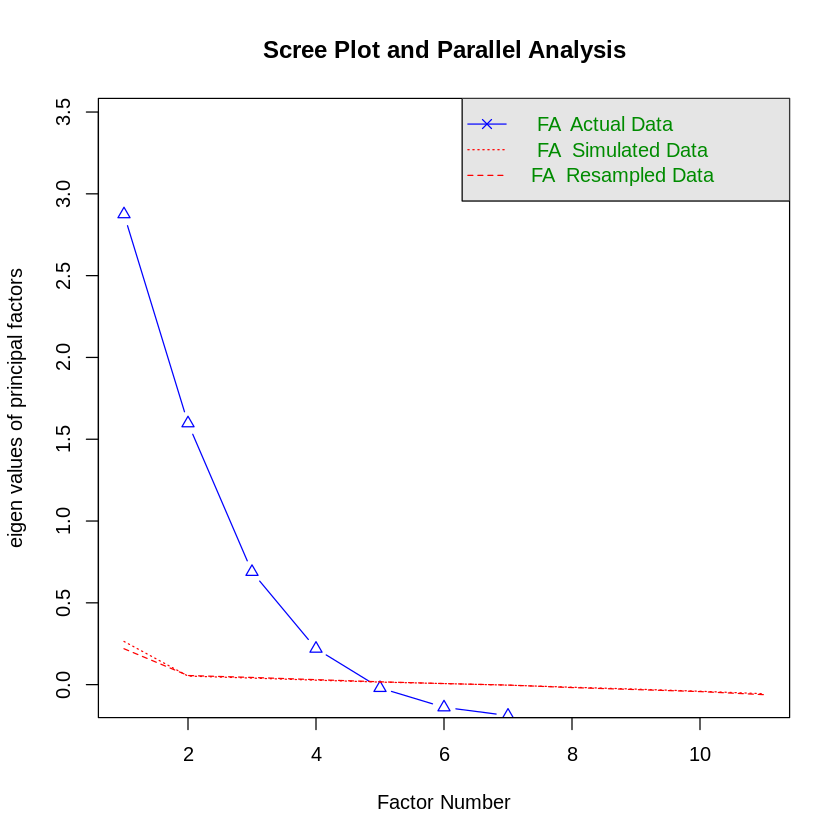

In [ ]:
numeric_all <- append(set_A,set_B)
set.seed(1234)

fa.parallel(df%>%select(numeric_all),
            fa = "fa",
            fm = "pa",
            show.legend = TRUE,
            main = "Scree Plot and Parallel Analysis")

In [ ]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘e1071’, ‘ModelMetrics’, ‘pROC’, ‘recipes’




In [ ]:
library(caret)

numeric_df <- df%>%select(numeric_all)

efa_vari4 <- fa(numeric_df, nfactors = 4, rotate = "varimax", fm = "pa")

maximum iteration exceeded

Warning message in fa.stats(r = r, f = f, phi = phi, n.obs = n.obs, np.obs = np.obs, :
“The estimated weights for the factor scores are probably incorrect.  Try a different factor score estimation method.”
Warning message in fac(r = r, nfactors = nfactors, n.obs = n.obs, rotate = rotate, :
“An ultra-Heywood case was detected.  Examine the results carefully”


In [ ]:
summary(efa_vari4)


Factor analysis with Call: fa(r = numeric_df, nfactors = 4, rotate = "varimax", fm = "pa")

Test of the hypothesis that 4 factors are sufficient.
The degrees of freedom for the model is 17  and the objective function was  1.19 
The number of observations was  5984  with Chi Square =  7139.46  with prob <  0 

The root mean square of the residuals (RMSA) is  0.03 
The df corrected root mean square of the residuals is  0.06 

Tucker Lewis Index of factoring reliability =  0.408
RMSEA index =  0.265  and the 90 % confidence intervals are  0.259 0.27
BIC =  6991.61

In [ ]:
print(efa_vari4,cut = 0.4)

Factor Analysis using method =  pa
Call: fa(r = numeric_df, nfactors = 4, rotate = "varimax", fm = "pa")
Standardized loadings (pattern matrix) based upon correlation matrix
                       PA1   PA2   PA3   PA4   h2    u2 com
free_sulfur_dioxide  -0.72                   0.59  0.41 1.3
total_sulfur_dioxide -0.84                   0.81  0.19 1.3
citric_acid                       0.83       0.71  0.29 1.1
alcohol                    -0.71             0.50  0.50 1.0
residual_sugar              0.56             0.52  0.48 2.2
volatile_acidity      0.54       -0.45       0.53  0.47 2.2
fixed_acidity         0.64                   0.62  0.38 2.1
chlorides             0.61                   0.57  0.43 2.0
density                     1.07             1.24 -0.24 1.2
sulphates                                    0.29  0.71 2.3
pH                                      0.84 0.79  0.21 1.2

                       PA1  PA2  PA3  PA4
SS loadings           2.70 2.26 1.19 1.02
Proportion Var       

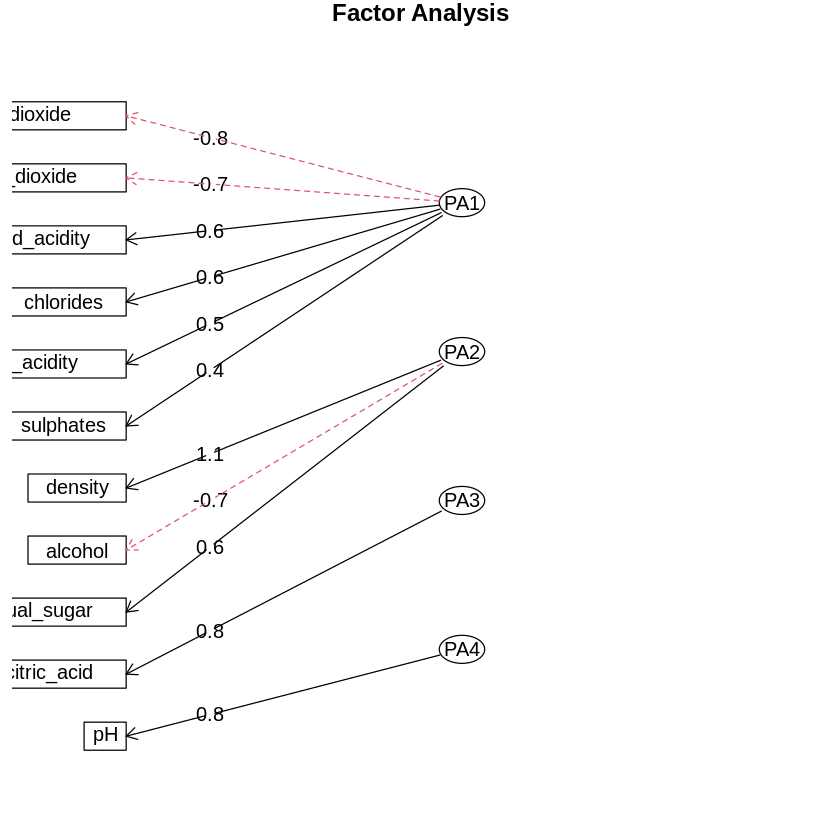

In [ ]:
fa.diagram(efa_vari4)